# Forecasting the exports volume of processed seafood in Thailand

## 1. Importing Required Libraries
In this cell, we load all the necessary Python libraries used for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`), and machine learning model creation and evaluation (`scikit-learn`).

In [17]:
# Importing standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# Importing machine learning tools
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

## 2. Convert Excel File to CSV 
This script loads an Excel file using the `pandas` library and converts it to a CSV file.

It uses UTF-8 with BOM encoding to ensure compatibility with Excel and excludes the index column from the output.

In [18]:
# Load the .xlsx file (default sheet)
df = pd.read_excel('DATA/Export 2007-2024.xlsx')  # tu peux ajouter sheet_name='NomDeLaFeuille' si nécessaire

# Save as .csv
df.to_csv('DATA/Export 2007-2024.csv', index=False,encoding="utf-8-sig")  # index=False pour ne pas inclure la colonne d’index

## 2. Data Loading, Cleaning, and Feature Engineering
In this section, we prepare the export dataset for modeling. The process includes:
- Loading the CSV file containing monthly seafood export records from 2007 to 2024.
- Creating a datetime column by combining the Year and Month columns, enabling proper chronological sorting and time-based analysis.
- Filtering the dataset by removing rows where all product-related quantities and values are equal to zero, as these records likely represent missing or irrelevant data.
- Sorting the dataset by date to preserve temporal order.
- Generating a numerical time feature called month_num, which represents the number of months elapsed since the beginning of the dataset. This variable is used as the main input for forecasting models.

In [22]:
# Load the CSV file
df = pd.read_csv("DATA/Export 2007-2024.csv")

# Create a datetime column from year and month
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))

# Function to remove rows where all specified columns have a value of 0.0
def supprimer_lignes_tous_zero_colonnes(df, colonnes):
    return df[~df[colonnes].eq(0.0).all(axis=1)]

df = supprimer_lignes_tous_zero_colonnes(df, [
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
    'Chilled/Frozen Fresh Shrimp Value (Million Baht)',
    'Dried Shrimp Quantity (Tons)',
    'Dried Shrimp Value (Million Baht)',
    'Boiled or Steamed Shrimp Quantity (Tons)',
    'Boiled or Steamed Shrimp Value (Million Baht)',
    'Shrimp in Airtight Containers Quantity (Tons)',
    'Shrimp in Airtight Containers Value (Million Baht)',
    'Preserved or Processed Shrimp Quantity (Tons)',
    'Preserved or Processed Shrimp Value (Million Baht)',
    'Shrimp Quantity (Tons)',
    'Shrimp Value (Million Baht)',
    'Chilled/Frozen Fresh Squid Quantity (Tons)',
    'Chilled/Frozen Fresh Squid Value (Million Baht)',
    'Dried Squid Quantity (Tons)',
    'Dried Squid Value (Million Baht)',
    'Processed or Preserved Squid Quantity (Tons)',
    'Processed or Preserved Squid Value (Million Baht)',
    'Smoked squid Quantity (Tons)',
    'Smoked squid Value (Million Baht)',
    'Squid Quantity (Tons)',
    'Squid Value (Million Baht)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
    'Chilled/Frozen Fresh Fish (including liver and roe) Value (Million Baht)',
    'Chilled/Frozen Fish Fillets Quantity (Tons)',
    'Chilled/Frozen Fish Fillets Value (Million Baht)',
    'Dried Fish Quantity (Tons)',
    'Dried Fish Value (Million Baht)',
    'Live Fish and Fish Breeding Stock Quantity (Tons)',
    'Live Fish and Fish Breeding Stock Value (Million Baht)',
    'Fish Quantity (Tons)',
    'Fish Value (Million Baht)',
    'Canned Tuna Quantity (Tons)',
    'Canned Tuna Value (Million Baht)',
    'Canned Sardines Quantity (Tons)',
    'Canned Sardines Value (Million Baht)',
    'Other Canned Fish Quantity (Tons)',
    'Other Canned Fish Value (Million Baht)',
    'Canned Crab Quantity (Tons)',
    'Canned Crab Value (Million Baht)',
    'Other Canned Seafood Quantity (Tons)',
    'Other Canned Seafood Value (Million Baht)',
    'Canned Products Quantity (Tons)',
    'Canned Products Value (Million Baht)',
    'Canned Dog and Cat Food Quantity (Tons)',
    'Canned Dog and Cat Food Value (Million Baht)',
    'Processed Seafood Products Quantity (Tons)',
    'Processed Seafood Products Value (Million Baht)',
    'Processed Tuna Products Quantity (Tons)',
    'Processed Tuna Products Value (Million Baht)',
    'Preserved or Processed Crab Quantity (Tons)',
    'Preserved or Processed Crab Value (Million Baht)',
    'Other Processed Seafood Products Quantity (Tons)',
    'Other Processed Seafood Products Value (Million Baht)',
    'Other Fishery Products Quantity (Tons)',
    'Other Fishery Products Value (Million Baht)',
    'Grand Total Quantity (Tons)',
    'Grand Total Value (Million Baht)'])

# Sort the dataset by month
df = df.sort_values('month')

# Create a numerical time feature (number of months since start)
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')

## 3. Models

### 3.1 Model Selection

We are testing several machine learning models:

* Logistic Regression
* SVM (Support Vector Machine)
* Decision Trees
* Random Forest
* K-Nearest Neighbors (KNN)

We will apply the same training method to the different models we are going to test and compare their performance.

### 3.2 Splitting the Dataset for Cross-Validation

We use 5-fold cross-validation with stratified sampling to evaluate model performance more reliably:
* The dataset is split into 5 distinct subsets of equal size.
* For each iteration, 80% of the data is used for training and the remaining 20% is used for testing, without overlap between test sets.
* This ensures that every data point is used exactly once for testing, allowing a more robust and generalized evaluation of the model.
* Stratified splitting ensures that each fold preserves the original class distribution, which is particularly important for imbalanced datasets.

### 3.3 Model Evaluation Methodology

In this section, we implement a comparative analysis of several machine learning models to forecast Thailand’s monthly seafood export volume. The methodology consists of the following steps:

- **Data Preparation**:
We use cleaned and time-encoded data including a numerical time index and cyclical features (month sine and cosine) to capture seasonality.

- **Validation Strategy**:
A TimeSeriesSplit with 5 folds is used to respect the chronological order of the data during training and evaluation.

- **Performance Metrics**:
For each model and fold, we compute:

    - Root Mean Squared Error (RMSE)

    - R² Score (Coefficient of Determination)
Average and standard deviation values are calculated to assess both accuracy and consistency

- **Visualization**:

    - For the last fold of each model, a scatter plot is generated comparing actual vs. predicted values.

    - A final forecasting plot displays each model’s predicted export volume from the start of the dataset up to 2030, along with the actual historical data for comparison.

This approach allows us to identify which model best captures the trends and seasonal behavior in export quantities, while also testing their generalization capability beyond the observed data.

### 3.4 Applying the Models


=== Linear Regression ===

--- Fold 1 ---
RMSE: 13961.7851
R²: 0.0430

--- Fold 2 ---
RMSE: 21492.5861
R²: -3.2249

--- Fold 3 ---
RMSE: 14139.9536
R²: -0.4877

--- Fold 4 ---
RMSE: 14063.6371
R²: -0.8916

--- Fold 5 ---
RMSE: 19991.3981
R²: -1.2974


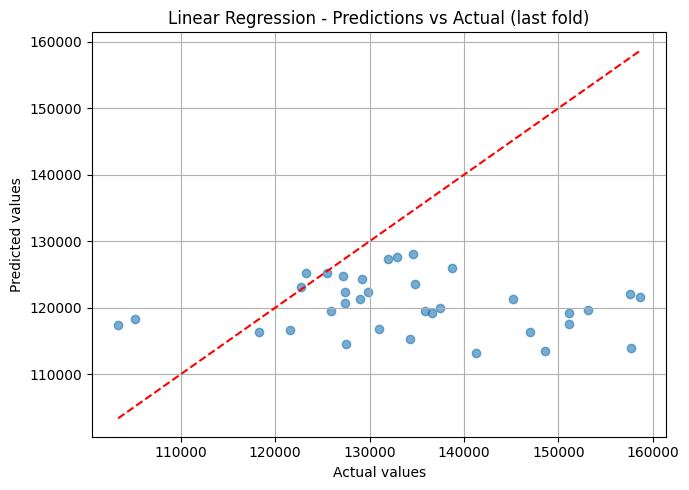


=== SVR ===

--- Fold 1 ---
RMSE: 14754.6254
R²: -0.0687

--- Fold 2 ---
RMSE: 21046.1845
R²: -3.0512

--- Fold 3 ---
RMSE: 28340.8471
R²: -4.9767

--- Fold 4 ---
RMSE: 20275.5112
R²: -2.9318

--- Fold 5 ---
RMSE: 16660.2716
R²: -0.5956


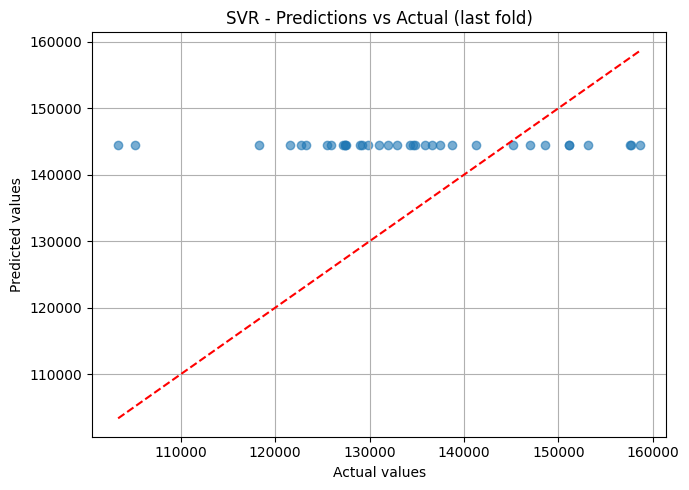


=== Decision Tree ===

--- Fold 1 ---
RMSE: 13157.3056
R²: 0.1501

--- Fold 2 ---
RMSE: 26085.3913
R²: -5.2235

--- Fold 3 ---
RMSE: 13636.5714
R²: -0.3837

--- Fold 4 ---
RMSE: 11038.2821
R²: -0.1653

--- Fold 5 ---
RMSE: 14294.9379
R²: -0.1747


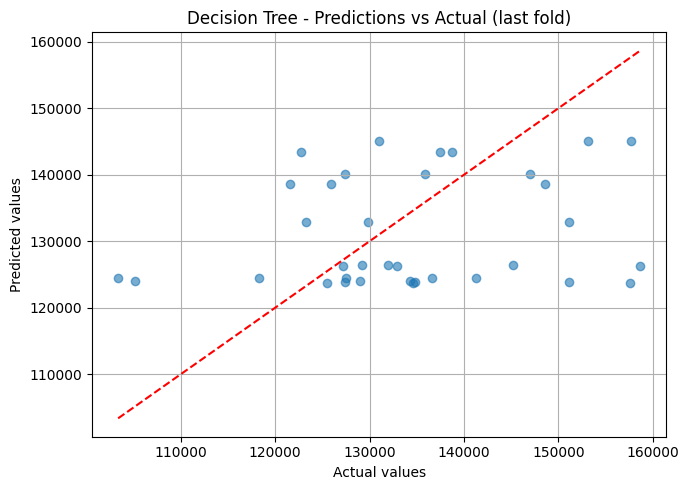


=== Random Forest ===

--- Fold 1 ---
RMSE: 12196.0714
R²: 0.2698

--- Fold 2 ---
RMSE: 18719.3601
R²: -2.2049

--- Fold 3 ---
RMSE: 11743.6145
R²: -0.0262

--- Fold 4 ---
RMSE: 11047.5942
R²: -0.1673

--- Fold 5 ---
RMSE: 12451.6732
R²: 0.1087


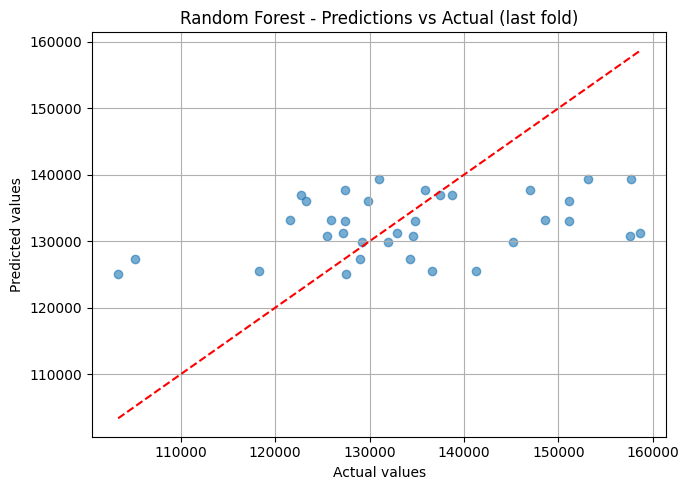


=== KNN ===

--- Fold 1 ---
RMSE: 14292.2445
R²: -0.0028

--- Fold 2 ---
RMSE: 15791.6621
R²: -1.2808

--- Fold 3 ---
RMSE: 13956.2199
R²: -0.4493

--- Fold 4 ---
RMSE: 11065.9176
R²: -0.1712

--- Fold 5 ---
RMSE: 13313.3142
R²: -0.0189


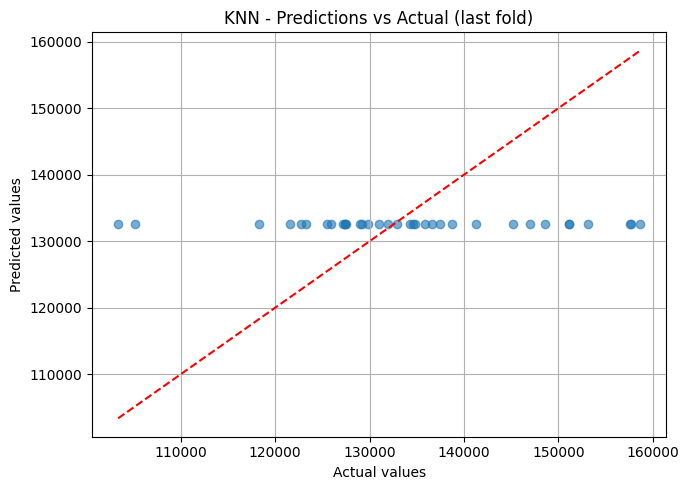


=== Summary of Results ===
                    RMSE mean   RMSE std  R² mean  R² std
Linear Regression  16729.8720  3310.5827  -1.1717  1.1183
SVR                20215.4880  4672.8087  -2.3248  1.7893
Decision Tree      15642.4976  5334.2041  -1.1594  2.0392
Random Forest      13231.6627  2784.9631  -0.4040  0.9120
KNN                13683.8717  1541.3026  -0.3846  0.4759


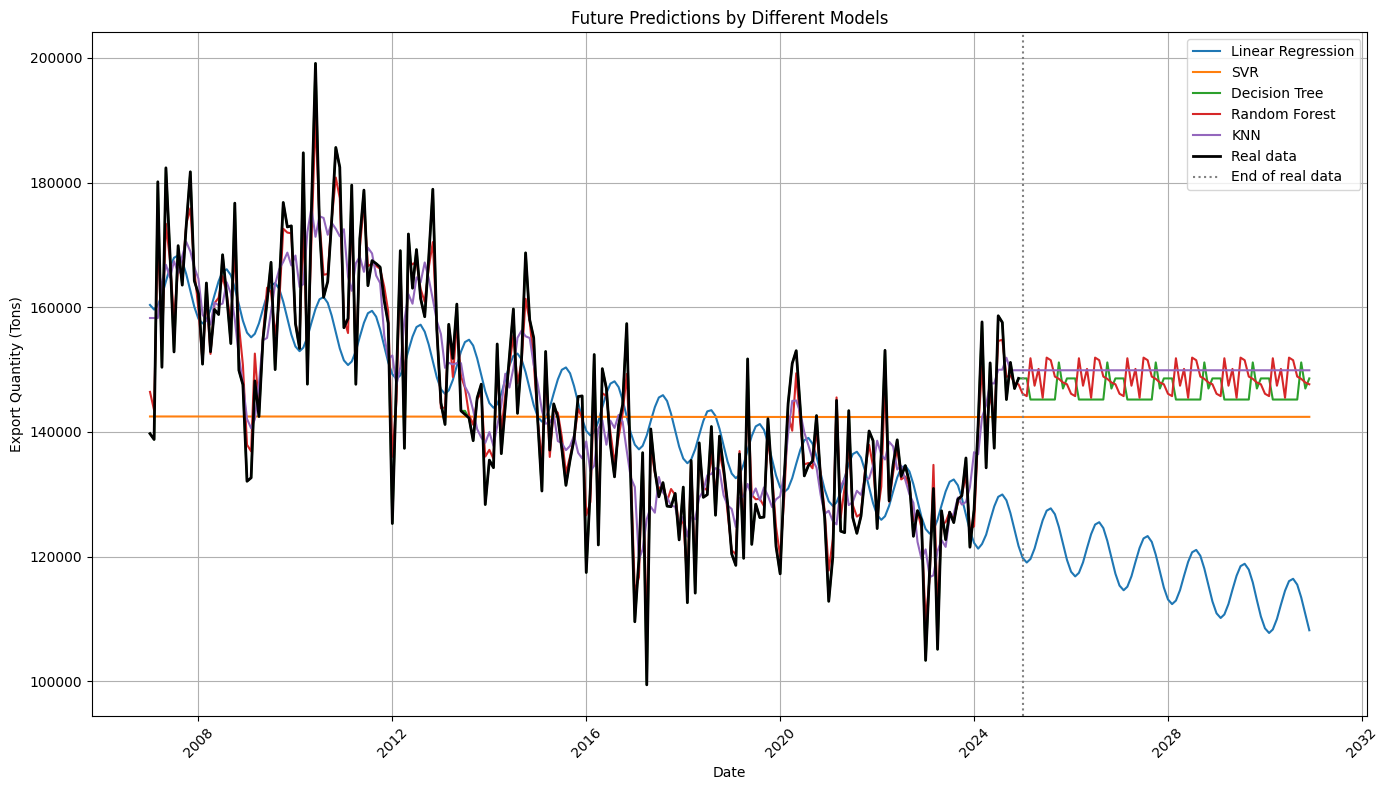

In [23]:
# --- Data loading and preprocessing ---

df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month

# Cyclical variables to handle seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# --- Models to evaluate ---

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        # Plot predictions vs actual values for the last fold
        if i == tscv.get_n_splits() - 1:  
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# --- Summary of results ---

summary_df = pd.DataFrame(results).T.round(4)

print("\n=== Summary of Results ===")
print(summary_df)

# --- Future prediction using all available data ---

all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})


plt.figure(figsize=(14, 8))

# Retrain model on the entire dataset
for name, model in models.items():
    
    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Hyperparameter Tuning 
In this section, we re-evaluate the five machine learning models using hyperparameter optimization to improve their performance.

### 4.1  Grid Search Hyperparameter Tuning for Regression Models

The goal is to determine the best combination of hyperparameters for each model using grid search combined with time series cross-validation `(TimeSeriesSplit)`, which ensures that the temporal order of the data is respected during training and validation.

**Key elements of this process:**
- A hyperparameter grid is defined for each model (except Linear Regression, which has no tunable hyperparameters).

- For each model, GridSearchCV tests all combinations of hyperparameters using 5-fold time series CV and evaluates them based on negative mean squared error.

- The best-performing model configuration (lowest RMSE) is saved for each algorithm.

- A summary table is printed showing:

    - The best hyperparameter set (Best Params)

    - The corresponding cross-validated RMSE (Best CV RMSE)

This tuning step aims to maximize the predictive accuracy of each model before proceeding to final evaluations and future forecasting.

In [24]:
# Définir la TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

# Dictionnaires de modèles et de grilles d'hyperparamètres
param_grids = {
    "Linear Regression": {},
    "SVR": {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.01, 0.1, 0.5]
    },
    "Decision Tree": {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "KNN": {
        'n_neighbors': [3, 5, 7, 10],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }
}

models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

best_models = {}
results = {}

for name, model in models.items():
    print(f"\n=== Hyperparameter tuning for {name} ===")
    
    param_grid = param_grids.get(name, {})
    
    if not param_grid:
        print("No hyperparameters to tune for this model.")
        model.fit(X, y)
        best_models[name] = model
        results[name] = {
            "Best Params": {},
            "Best CV RMSE": np.sqrt(mean_squared_error(y, model.predict(X)))
        }
        continue
    
    grid_search = GridSearchCV(
        model, 
        param_grid, 
        cv=tscv, 
        scoring='neg_mean_squared_error', 
        n_jobs=-1, 
        verbose=1
    )
    
    grid_search.fit(X, y)
    
    best_models[name] = grid_search.best_estimator_
    best_rmse = (-grid_search.best_score_) ** 0.5
    
    print(f"Best params for {name}: {grid_search.best_params_}")
    print(f"Best CV RMSE: {best_rmse:.4f}")
    
    results[name] = {
        "Best Params": grid_search.best_params_,
        "Best CV RMSE": best_rmse
    }

# Résumé
summary_df = pd.DataFrame(results).T
print("\n=== Summary of Hyperparameter Tuning Results ===")
print(summary_df)

# Stockage dans une variable exploitable
best_params_dict = {name: results[name]["Best Params"] for name in results}



=== Hyperparameter tuning for Linear Regression ===
No hyperparameters to tune for this model.

=== Hyperparameter tuning for SVR ===
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params for SVR: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale'}
Best CV RMSE: 20590.6514

=== Hyperparameter tuning for Decision Tree ===
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params for Decision Tree: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV RMSE: 13921.7242

=== Hyperparameter tuning for Random Forest ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE: 13357.0428

=== Hyperparameter tuning for KNN ===
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params for KNN: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Best CV RMSE: 13054.7777

=== Summary of Hyperparameter 

### 4.2  Evaluation of Optimized Models and Long-Term Forecasting

In this section, we re-evaluate all five machine learning models using their best hyperparameter configurations, obtained previously through grid search. Each model is validated using a 5-fold time series cross-validation to compute its predictive accuracy and stability.

**Methodology**:
- We use the same input features (month_num, month_sin, month_cos) and target (Grand Total Quantity (Tons)).

- For each model:

    - The model is trained and evaluated across 5 consecutive folds.

    - Performance metrics include: RMSE (Root Mean Squared Error) and R² Score (Coefficient of Determination)

    - A scatter plot is generated for the final fold, comparing actual vs. predicted values.

- A summary table of average performance is printed for model comparison.

- Finally, all models are re-trained on the full dataset and used to forecast seafood export volumes up to *December 2030*.

The results are visualized in a single plot showing each model's predicted trend alongside the historical data.

This step highlights how the tuned models perform under realistic, temporally ordered validation, and assesses their ability to extrapolate future export trends.


=== Linear Regression ===

--- Fold 1 ---
RMSE: 13961.7851
R²: 0.0430

--- Fold 2 ---
RMSE: 21492.5861
R²: -3.2249

--- Fold 3 ---
RMSE: 14139.9536
R²: -0.4877

--- Fold 4 ---
RMSE: 14063.6371
R²: -0.8916

--- Fold 5 ---
RMSE: 19991.3981
R²: -1.2974


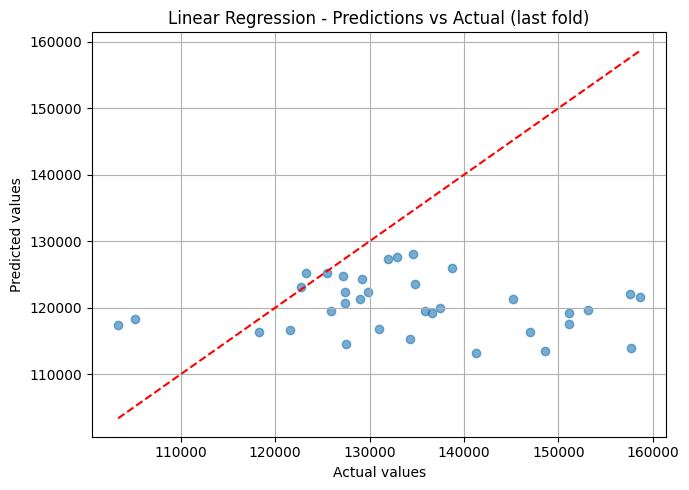


=== SVR ===

--- Fold 1 ---
RMSE: 14754.5118
R²: -0.0687

--- Fold 2 ---
RMSE: 21051.6542
R²: -3.0533

--- Fold 3 ---
RMSE: 28183.5888
R²: -4.9105

--- Fold 4 ---
RMSE: 19837.8669
R²: -2.7639

--- Fold 5 ---
RMSE: 16466.6702
R²: -0.5587


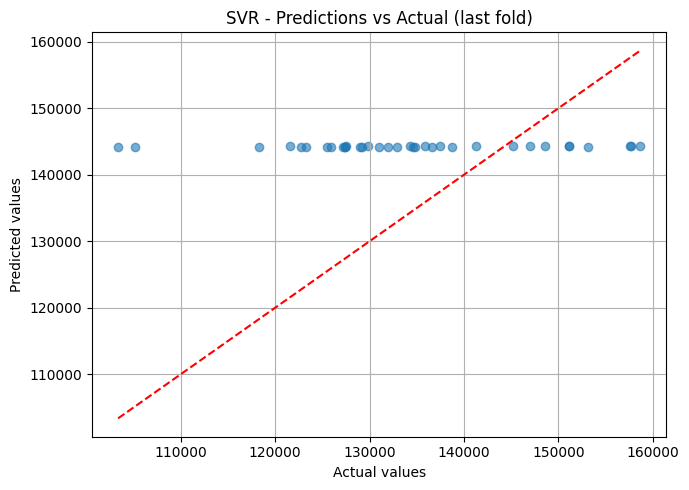


=== Decision Tree ===

--- Fold 1 ---
RMSE: 11500.9926
R²: 0.3506

--- Fold 2 ---
RMSE: 18124.6197
R²: -2.0045

--- Fold 3 ---
RMSE: 14284.2584
R²: -0.5183

--- Fold 4 ---
RMSE: 12154.4430
R²: -0.4129

--- Fold 5 ---
RMSE: 12511.0683
R²: 0.1002


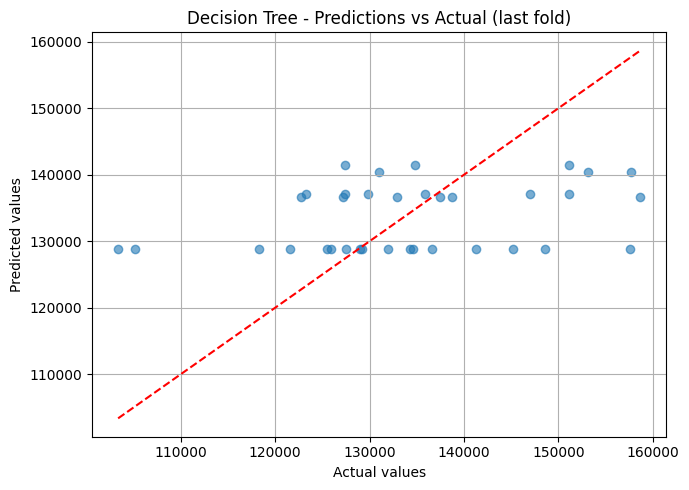


=== Random Forest ===

--- Fold 1 ---
RMSE: 11958.7606
R²: 0.2979

--- Fold 2 ---
RMSE: 18831.3350
R²: -2.2434

--- Fold 3 ---
RMSE: 10954.6876
R²: 0.1070

--- Fold 4 ---
RMSE: 10956.9763
R²: -0.1482

--- Fold 5 ---
RMSE: 12424.2233
R²: 0.1126


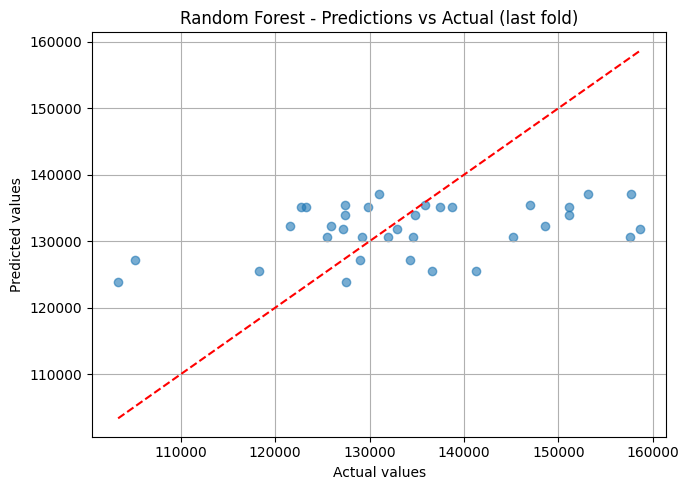


=== KNN ===

--- Fold 1 ---
RMSE: 14421.3840
R²: -0.0210

--- Fold 2 ---
RMSE: 11139.6225
R²: -0.1350

--- Fold 3 ---
RMSE: 11959.5515
R²: -0.0643

--- Fold 4 ---
RMSE: 14250.4425
R²: -0.9422

--- Fold 5 ---
RMSE: 13189.4890
R²: -0.0000


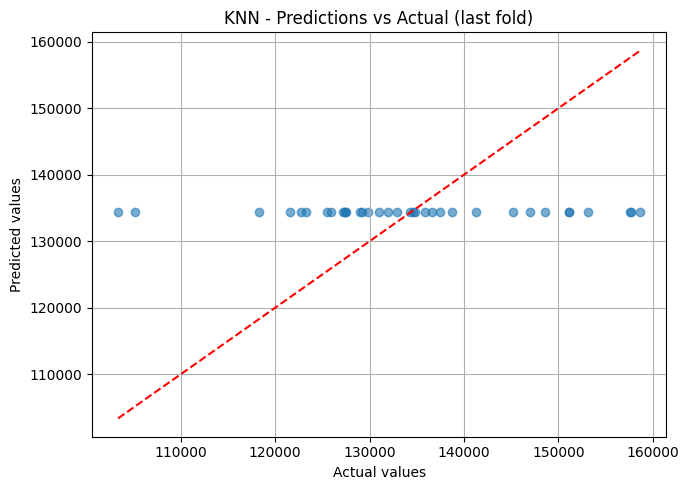


=== Summary of Results ===
                    RMSE mean   RMSE std  R² mean  R² std
Linear Regression  16729.8720  3310.5827  -1.1717  1.1183
SVR                20058.8584  4649.4222  -2.2710  1.7666
Decision Tree      13715.0764  2389.7874  -0.4970  0.8192
Random Forest      13025.1966  2958.8592  -0.3748  0.9450
KNN                12992.0979  1277.7379  -0.2325  0.3579


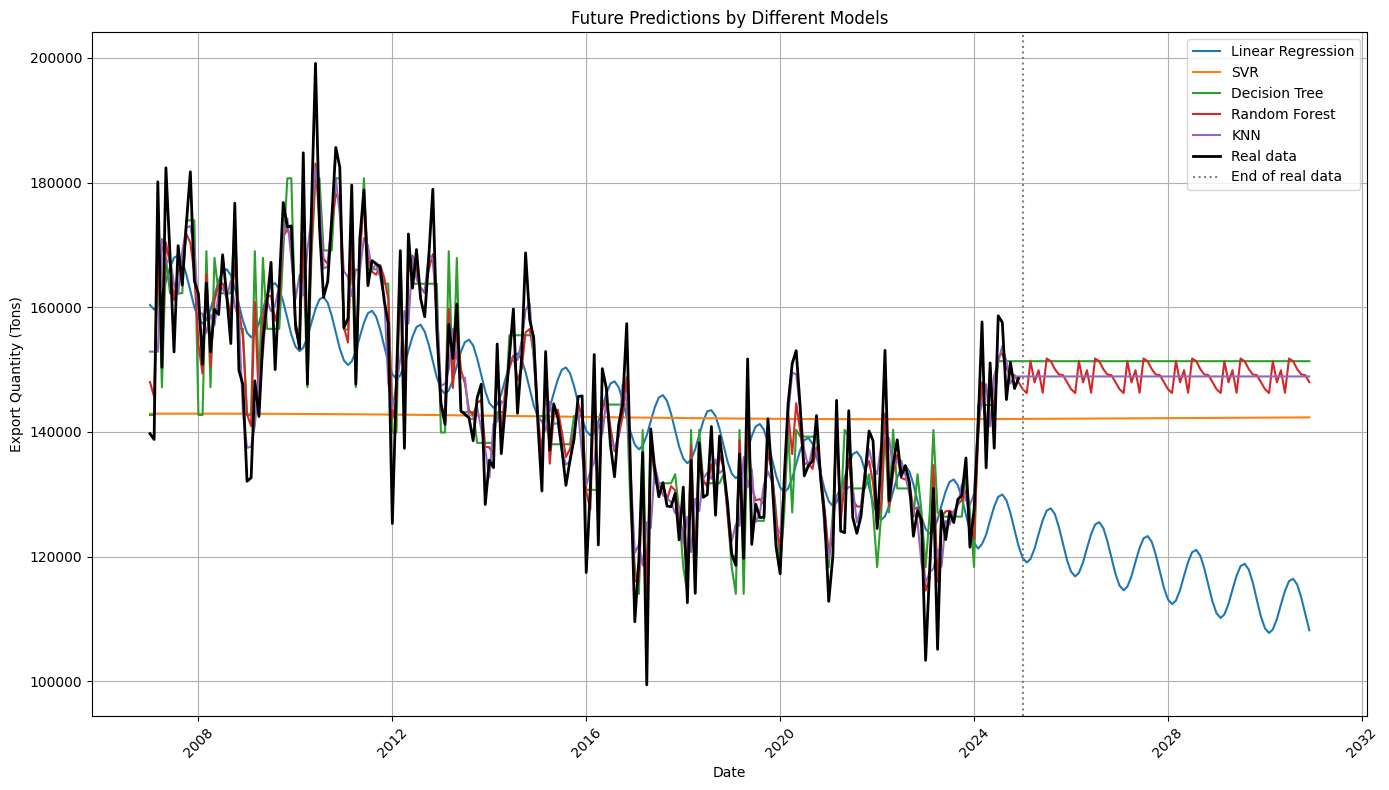

In [25]:
# Préparation des variables temporelles
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

X = df[['month_num', 'month_sin', 'month_cos']]
y = df['Grand Total Quantity (Tons)'].values

# Création dynamique des modèles à partir des meilleurs paramètres
models = {}
for name, base_model in {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}.items():
    if name in best_params_dict and best_params_dict[name]:
        models[name] = clone(base_model).set_params(**best_params_dict[name])
    else:
        models[name] = base_model

# Évaluation avec TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
results = {}

for name, model in models.items():
    rmse_scores = []
    r2_scores = []
    print(f"\n=== {name} ===")
    
    for i, (train_index, val_index) in enumerate(tscv.split(X)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        rmse_scores.append(rmse)
        r2_scores.append(r2)
        
        print(f"\n--- Fold {i+1} ---")
        print(f"RMSE: {rmse:.4f}")
        print(f"R²: {r2:.4f}")
        
        if i == tscv.get_n_splits() - 1:
            plt.figure(figsize=(7, 5))
            plt.scatter(y_val, y_pred, alpha=0.6)
            plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
            plt.xlabel("Actual values")
            plt.ylabel("Predicted values")
            plt.title(f"{name} - Predictions vs Actual (last fold)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    results[name] = {
        "RMSE mean": np.mean(rmse_scores),
        "RMSE std": np.std(rmse_scores),
        "R² mean": np.mean(r2_scores),
        "R² std": np.std(r2_scores)
    }

# Résumé
summary_df = pd.DataFrame(results).T.round(4)
print("\n=== Summary of Results ===")
print(summary_df)

# Prédictions futures
all_months = pd.date_range(start=df['month'].min(), end="2030-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos
})

plt.figure(figsize=(14, 8))

for name, model in models.items():
    model.fit(X, y)
    y_all_pred = model.predict(X_all)
    plt.plot(all_months, y_all_pred, label=name)

plt.plot(df['month'], y, label="Real data", color='black', linewidth=2)
plt.axvline(x=pd.to_datetime("2024-12-31"), color='grey', linestyle=':', label='End of real data')
plt.xlabel("Date")
plt.ylabel("Export Quantity (Tons)")
plt.title("Future Predictions by Different Models")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Final Forecast Using Random Forest with All Product Features

In this section, we build a comprehensive forecasting model using Random Forest Regressor with both temporal features and product-specific export quantities as inputs. The objective is to improve the accuracy of total export volume predictions (Grand Total Quantity (Tons)) by integrating historical patterns from multiple seafood categories.

### 5.1 Random Forest with Full Feature Set

In this block, we train and evaluate a Random Forest Regressor using a rich set of features that combine temporal indicators and historical export volumes for all major seafood product categories.

**Workflow:**
- The input matrix `X` includes:

    - Time-based features: `month_num`, `month_sin`, `month_cos`

    - Export quantities for 25 specific product categories (e.g., shrimp, fish, canned products).

- The target `y` is the total export quantity `(Grand Total Quantity (Tons))`.

- We evaluate the model using 5-fold time series cross-validation, computing the average and standard deviation of RMSE.

- After cross-validation, the model is retrained on the entire dataset to prepare for future forecasting.

This approach aims to improve the prediction of total seafood exports by leveraging trends observed in individual product lines.

In [26]:
# Prepare date column
df['month'] = pd.to_datetime(df['Year (ค.ศ.)'].astype(str) + '-' + df['Month'].astype(str).str.zfill(2))
df = df.sort_values('month')

# Add temporal variables
df['month_num'] = (df['month'] - df['month'].min()) // pd.Timedelta('30D')
df['month_of_year'] = df['month'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month_of_year'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_of_year'] / 12)

# Features + cible
X = df[['month_num', 'month_sin', 'month_cos']]

# Model

based_model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

model_Chilled_Frozen_Fresh_Shrimp = based_model
model_Shrimp_Airtight = based_model
model_Preserved_Processed_Shrimp= based_model
model_Shrimp= based_model
model_Chilled_Frozen_Fresh_Squid= based_model
model_Dried_Squid= based_model
model_Processed_Preserved_Squid= based_model
model_Squid= based_model
model_Chilled_Frozen_Fresh_Fish= based_model
model_Chilled_Frozen_Fish_Fillets= based_model
model_Dried_Fish= based_model
model_Live_Fish_Fish_Breeding_Stock= based_model
model_Fish= based_model
model_Canned_Tuna= based_model
model_Canned_Sardines= based_model
model_Other_Canned_Fish= based_model
model_Canned_Crab= based_model
model_Other_Canned_Seafood= based_model
model_Canned_Products= based_model
model_Canned_Dog_Cat_Food= based_model
model_Processed_Seafood_Products= based_model
model_Processed_Tuna_Products= based_model
model_Preserved_Processed_Crab= based_model
model_Other_Processed_Seafood_Products= based_model
model_Other_Fishery_Products= based_model

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

# ---------- scenario for 2025 ----------
# Create range
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)
mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]

# Dataframe creation for complete prediction
X_all = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
})

def prediction(model,y):
    for train_index, val_index in tscv.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        rmse = sqrt(mean_squared_error(y_val, y_pred))
        rmse_scores.append(rmse)


    model.fit(X, y)

    y_all_pred = model.predict(X_all)

    return y_all_pred

prediction_chilled_Shrimp = prediction(model_Chilled_Frozen_Fresh_Shrimp, df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'].values)
prediction_Shrimp_Airtight = prediction(model_Shrimp_Airtight, df['Shrimp in Airtight Containers Quantity (Tons)'].values)
prediction_Shrimp_Processed = prediction(model_Preserved_Processed_Shrimp, df['Preserved or Processed Shrimp Quantity (Tons)'].values)
prediction_Shrimp = prediction(model_Shrimp,df['Shrimp Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Squid = prediction(model_Chilled_Frozen_Fresh_Squid, df['Chilled/Frozen Fresh Squid Quantity (Tons)'].values)
prediction_Dried_Squid = prediction(model_Dried_Squid, df['Dried Squid Quantity (Tons)'].values)
prediction_Processed_Preserved_Squid = prediction(model_Processed_Preserved_Squid, df['Processed or Preserved Squid Quantity (Tons)'].values)
prediction_Squid = prediction(model_Squid, df['Squid Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fresh_Fish = prediction(model_Chilled_Frozen_Fresh_Fish, df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'].values)
prediction_Chilled_Frozen_Fish_Fillets = prediction(model_Chilled_Frozen_Fish_Fillets, df['Chilled/Frozen Fish Fillets Quantity (Tons)'].values)
prediction_Dried_Fish = prediction(model_Dried_Fish, df['Dried Fish Quantity (Tons)'].values)
prediction_Live_Fish_Fish_Breeding_Stock = prediction(model_Live_Fish_Fish_Breeding_Stock, df['Dried Fish Quantity (Tons)'].values)
prediction_Fish = prediction(model_Fish,df['Fish Quantity (Tons)'].values)
prediction_Canned_Tuna = prediction(model_Canned_Tuna,df['Canned Tuna Quantity (Tons)'].values)
prediction_Canned_Sardines = prediction(model_Canned_Sardines,df['Canned Sardines Quantity (Tons)'].values)
prediction_Other_Canned_Fish = prediction(model_Other_Canned_Fish,df['Other Canned Fish Quantity (Tons)'].values)
prediction_Canned_Crab = prediction(model_Canned_Crab,df['Canned Crab Quantity (Tons)'].values)
prediction_Other_Canned_Seafood = prediction(model_Other_Canned_Seafood,df['Other Canned Seafood Quantity (Tons)'].values)
prediction_Canned_Products = prediction(model_Canned_Products,df['Canned Products Quantity (Tons)'].values)
prediction_Canned_Dog_Cat_Food = prediction(model_Canned_Dog_Cat_Food,df['Canned Dog and Cat Food Quantity (Tons)'].values)
prediction_Processed_Seafood_Products = prediction(model_Processed_Seafood_Products,df['Processed Seafood Products Quantity (Tons)'].values)
prediction_Processed_Tuna_Products = prediction(model_Processed_Tuna_Products,df['Processed Tuna Products Quantity (Tons)'].values)
prediction_Preserved_Processed_Crab  = prediction(model_Preserved_Processed_Crab,df['Preserved or Processed Crab Quantity (Tons)'].values)
prediction_Other_Processed_Seafood_Products  = prediction(model_Other_Processed_Seafood_Products,df['Other Processed Seafood Products Quantity (Tons)'].values)
prediction_Other_Fishery_Products = prediction(model_Other_Fishery_Products,df['Other Fishery Products Quantity (Tons)'].values)

X_Future = pd.DataFrame({
    'month_num': all_month_nums,
    'month_sin': all_month_sin,
    'month_cos': all_month_cos,
    'Chilled/Frozen Fresh Shrimp Quantity (Tons)':prediction_chilled_Shrimp,
    'Shrimp in Airtight Containers Quantity (Tons)':prediction_Shrimp_Airtight,
    'Preserved or Processed Shrimp Quantity (Tons)':prediction_Shrimp_Processed,
    'Shrimp Quantity (Tons)':prediction_Shrimp,
    'Chilled/Frozen Fresh Squid Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Squid,
    'Dried Squid Quantity (Tons)':prediction_Dried_Squid,
    'Processed or Preserved Squid Quantity (Tons)':prediction_Processed_Preserved_Squid,
    'Squid Quantity (Tons)':prediction_Squid,
    'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)':prediction_Chilled_Frozen_Fresh_Fish,
    'Chilled/Frozen Fish Fillets Quantity (Tons)':prediction_Chilled_Frozen_Fish_Fillets,
    'Dried Fish Quantity (Tons)':prediction_Dried_Fish,
    'Live Fish and Fish Breeding Stock Quantity (Tons)':prediction_Live_Fish_Fish_Breeding_Stock,
    'Fish Quantity (Tons)':prediction_Fish,
    'Canned Tuna Quantity (Tons)':prediction_Canned_Tuna,
    'Canned Sardines Quantity (Tons)':prediction_Canned_Sardines,
    'Other Canned Fish Quantity (Tons)':prediction_Other_Canned_Fish,
    'Canned Crab Quantity (Tons)':prediction_Canned_Crab,
    'Other Canned Seafood Quantity (Tons)':prediction_Other_Canned_Seafood,
    'Canned Products Quantity (Tons)':prediction_Canned_Products,
    'Canned Dog and Cat Food Quantity (Tons)':prediction_Canned_Dog_Cat_Food,
    'Processed Seafood Products Quantity (Tons)':prediction_Processed_Seafood_Products,
    'Processed Tuna Products Quantity (Tons)':prediction_Processed_Tuna_Products,
    'Preserved or Processed Crab Quantity (Tons)':prediction_Preserved_Processed_Crab ,
    'Other Processed Seafood Products Quantity (Tons)':prediction_Other_Processed_Seafood_Products ,
    'Other Fishery Products Quantity (Tons)':prediction_Other_Fishery_Products
})

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

RMSE CV: Moyenne = 1960.97, Écart-type = 2210.13


### 5.2 Forecasting Total Exports with Predicted Category-Level Inputs

In this block, we use the trained Random Forest model to forecast total export quantities up to December 2025, using the predicted values of each product category as inputs.

**Key steps:**
- Future months from the dataset start until end of 2025 are generated and encoded as temporal features (`month_num`, `month_sin`, `month_cos`).

- Forecast inputs are taken from the previously built `X_Future` dataset, which includes predicted export quantities for each product type.

- The model predicts the total export volume (`y_all_pred`) based on these inputs.

- A final line plot shows:

    - Historical data in blue dashed line.

    - Forecasted total exports in green dashed line.

    - A vertical marker at *December 2024*, which separates observed and forecasted periods.

This visualization provides a forward-looking estimate of how Thailand’s total seafood exports might evolve under current trends across individual product segments.

RMSE CV: Moyenne = 9773.01, Écart-type = 1791.33


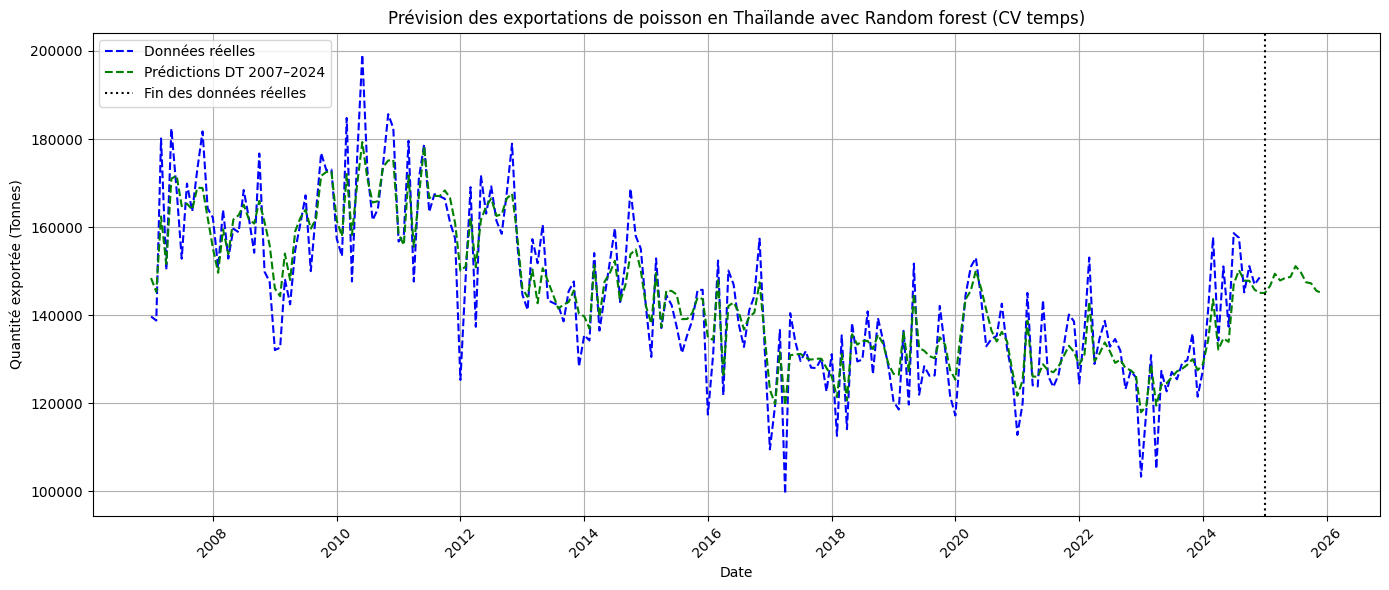

In [27]:
# features and target
X = df[['month_num', 'month_sin', 'month_cos', 
        'Chilled/Frozen Fresh Shrimp Quantity (Tons)',
        'Shrimp in Airtight Containers Quantity (Tons)',
        'Preserved or Processed Shrimp Quantity (Tons)',
        'Shrimp Quantity (Tons)',
        'Chilled/Frozen Fresh Squid Quantity (Tons)',
        'Dried Squid Quantity (Tons)',
        'Processed or Preserved Squid Quantity (Tons)',
        'Squid Quantity (Tons)',
        'Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)',
        'Chilled/Frozen Fish Fillets Quantity (Tons)',
        'Dried Fish Quantity (Tons)',
        'Live Fish and Fish Breeding Stock Quantity (Tons)',
        'Fish Quantity (Tons)',
        'Canned Tuna Quantity (Tons)',
        'Canned Sardines Quantity (Tons)',
        'Other Canned Fish Quantity (Tons)',
        'Canned Crab Quantity (Tons)',
        'Other Canned Seafood Quantity (Tons)',
        'Canned Products Quantity (Tons)',
        'Canned Dog and Cat Food Quantity (Tons)',
        'Processed Seafood Products Quantity (Tons)',
        'Processed Tuna Products Quantity (Tons)',
        'Preserved or Processed Crab Quantity (Tons)',
        'Other Processed Seafood Products Quantity (Tons)',
        'Other Fishery Products Quantity (Tons)',
        ]]
y = df['Grand Total Quantity (Tons)'].values

# DecisionTree
model = RandomForestRegressor(max_depth= 20, min_samples_leaf= 1, min_samples_split= 5, n_estimators= 200)

# Temporal cross validation
tscv = TimeSeriesSplit(n_splits=5)
rmse_scores = []

for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = sqrt(mean_squared_error(y_val, y_pred))
    rmse_scores.append(rmse)

print(f"RMSE CV: Moyenne = {np.mean(rmse_scores):.2f}, Écart-type = {np.std(rmse_scores):.2f}")

# Training
model.fit(X, y)

# Months generation to 2025-12
all_months = pd.date_range(start=df['month'].min(), end="2025-12-01", freq='MS')
all_month_nums = ((all_months - df['month'].min()) // pd.Timedelta('30D')).astype(int)
all_month_of_year = all_months.month
all_month_sin = np.sin(2 * np.pi * all_month_of_year / 12)
all_month_cos = np.cos(2 * np.pi * all_month_of_year / 12)

mask = all_months != pd.to_datetime("2013-07-01")

all_months = all_months[mask]
all_month_nums = all_month_nums[mask]
all_month_sin = all_month_sin[mask]
all_month_cos = all_month_cos[mask]


# Forecasting
y_all_pred = model.predict(X_Future)

# Display
plt.figure(figsize=(14, 6))
plt.plot(df['month'], y, label="Données réelles",  linestyle="--",color='blue')
plt.plot(all_months, y_all_pred, label="Prédictions DT 2007–2024", linestyle="--", color='green')
plt.axvline(x=pd.to_datetime("2024-12-31"), color='black', linestyle=':', label='Fin des données réelles')
plt.xlabel("Date")
plt.ylabel("Quantité exportée (Tonnes)")
plt.title("Prévision des exportations de poisson en Thaïlande avec Random forest (CV temps)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# PARIE 6

Starting LSTM application with hyperparameter optimization (Multivariate)...
Using existing 'df' DataFrame.
Number of features for LSTM: 8

Starting hyperparameter optimization with Keras Tuner...

Best hyperparameters found :
{'time_step': 6, 'units_1': 256, 'return_sequences': False, 'dropout_1': 0.30000000000000004, 'learning_rate': 0.0001, 'units_2': 64, 'dropout_2': 0.2}
Optimal time_step found: 6

Shape of X_train (optimal): (167, 6, 8)
Shape of y_train (optimal): (167,)
Shape of X_test (optimal): (42, 6, 8)
Shape of y_test (optimal): (42,)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 256)               271360    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             

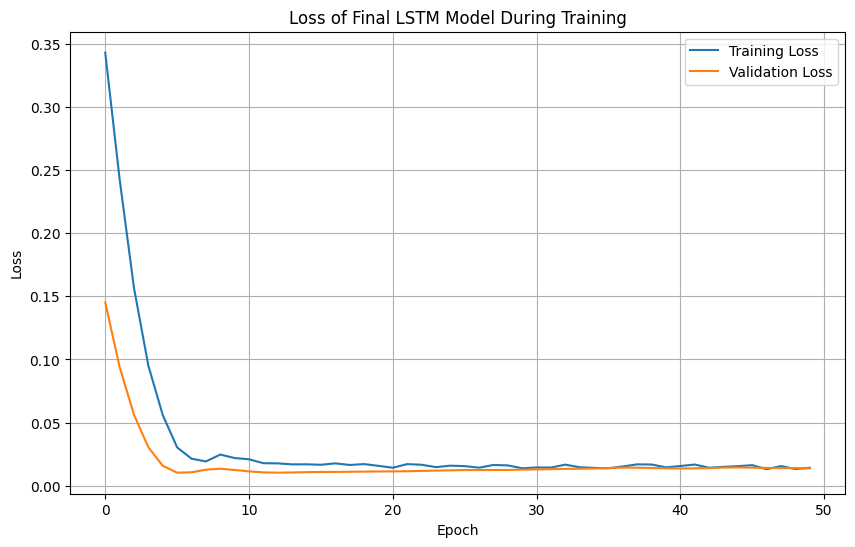


Making predictions on the test set...
2/2 [==============================] - 0s 3ms/step

RMSE (training): 11245.3033
MAE (training): 8978.3690
RMSE (test): 12515.6327
MAE (test): 9320.2478


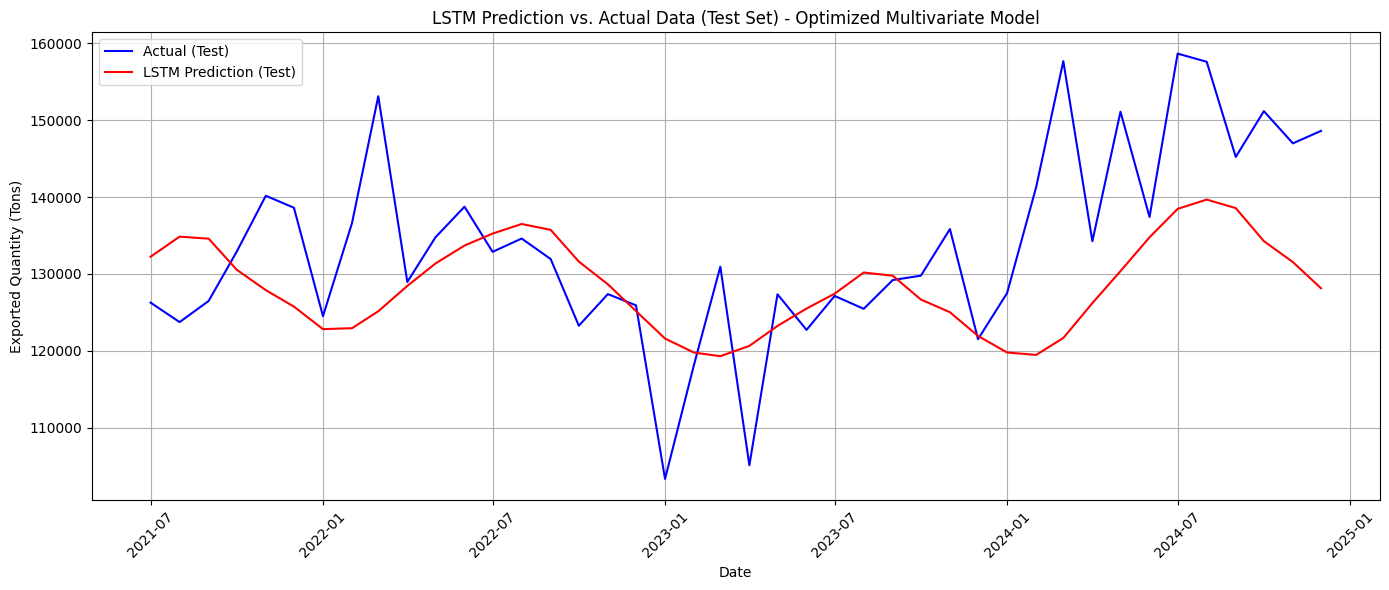

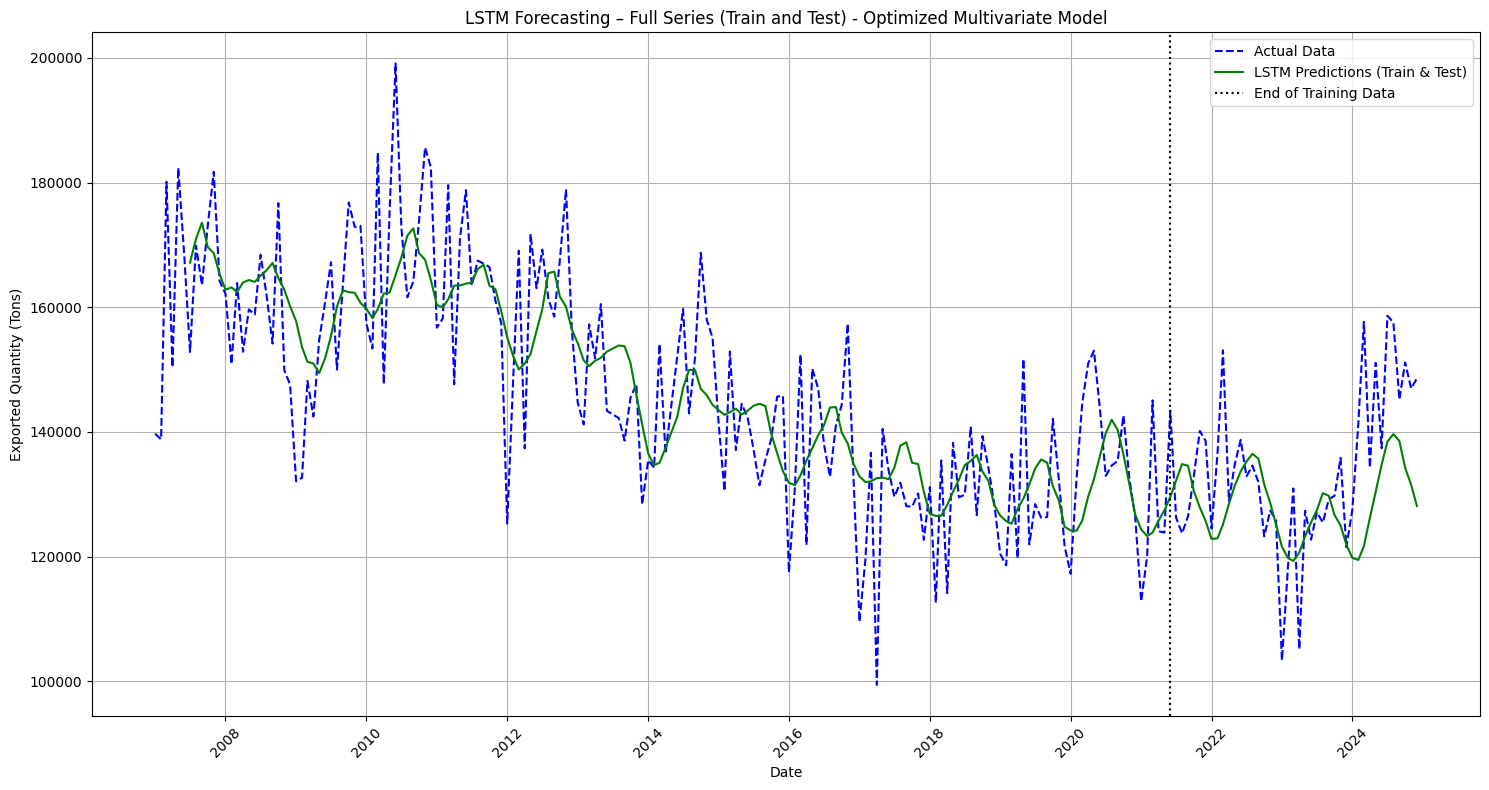


Making future predictions with the optimized Multivariate LSTM model...


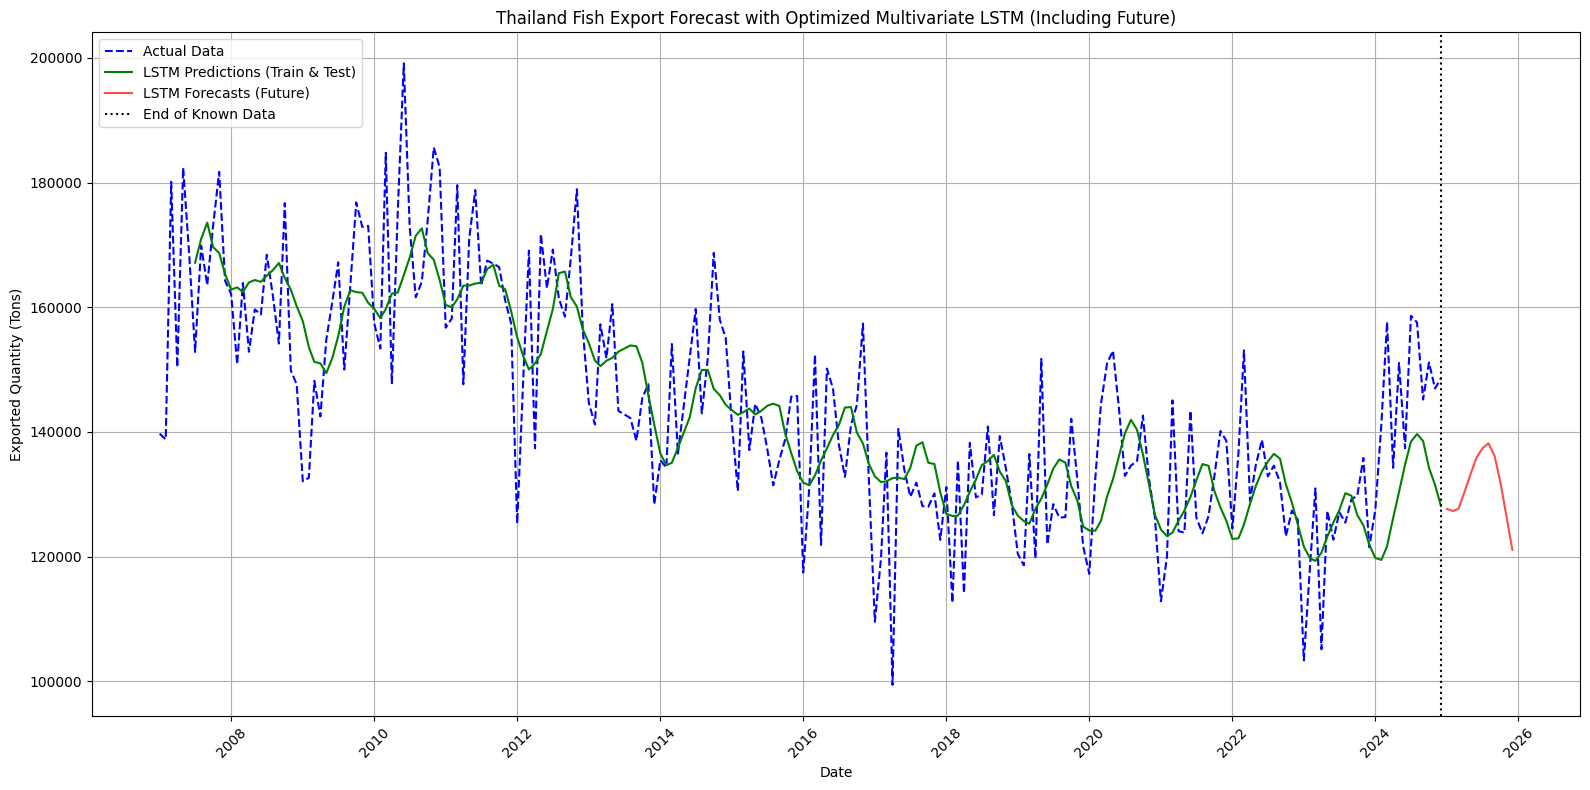


Residual Analysis: Autocorrelation (ACF) and Partial Autocorrelation (PACF)


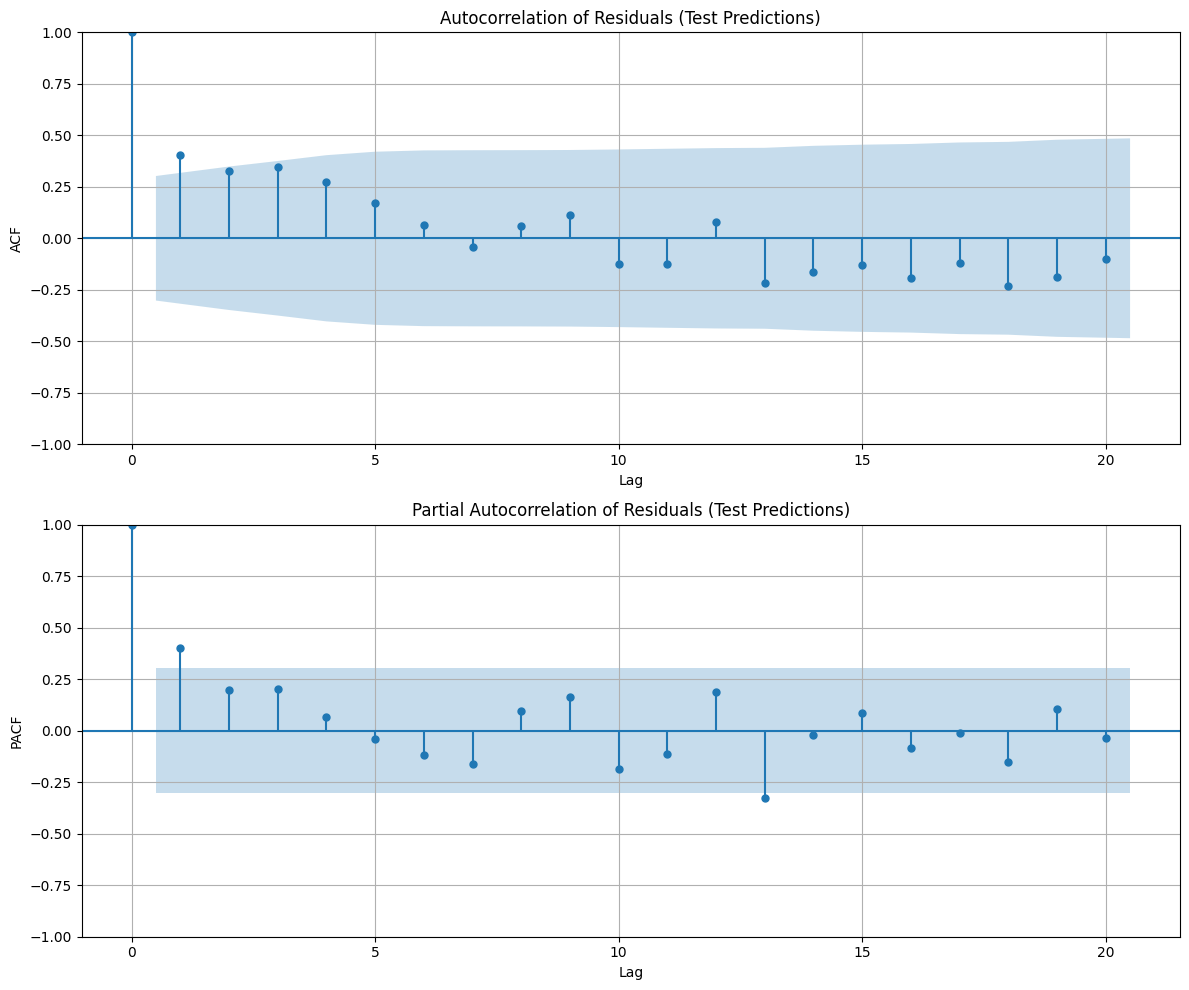


Finished LSTM application with hyperparameter optimization.


In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

print("Starting LSTM application with hyperparameter optimization (Multivariate)...")

# --- 0. Load and Initial Prepare of the DataFrame (df) ---
# Ensure your 'df' DataFrame is loaded here.
# For demonstration purposes, a synthetic DataFrame is created if 'df' is not found.
try:
    if 'df' not in locals() and 'df' not in globals():
        print("DataFrame 'df' not found. Creating synthetic data for example purposes.")
        dates = pd.date_range(start='2007-01-01', end='2024-12-01', freq='MS')
        quantities = np.sin(np.linspace(0, 50, len(dates))) * 1000 + 5000 + np.random.normal(0, 500, len(dates))
        df = pd.DataFrame({'month': dates, 'Grand Total Quantity (Tons)': quantities})
        df['month_num'] = ((df['month'] - df['month'].min()) // pd.Timedelta('30D')).astype(int)
        df['month_sin'] = np.sin(2 * np.pi * df['month'].dt.month / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'].dt.month / 12)
        # Adding dummy feature columns to simulate your actual data structure
        df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'] = np.random.rand(len(df)) * 500 + 1000
        df['Shrimp in Airtight Containers Quantity (Tons)'] = np.random.rand(len(df)) * 300 + 500
        df['Preserved or Processed Shrimp Quantity (Tons)'] = np.random.rand(len(df)) * 200 + 300
        df['Shrimp Quantity (Tons)'] = df['Chilled/Frozen Fresh Shrimp Quantity (Tons)'] + df['Shrimp in Airtight Containers Quantity (Tons)'] + df['Preserved or Processed Shrimp Quantity (Tons)']

        df['Chilled/Frozen Fresh Squid Quantity (Tons)'] = np.random.rand(len(df)) * 400 + 800
        df['Dried Squid Quantity (Tons)'] = np.random.rand(len(df)) * 150 + 200
        df['Processed or Preserved Squid Quantity (Tons)'] = np.random.rand(len(df)) * 100 + 150
        df['Squid Quantity (Tons)'] = df['Chilled/Frozen Fresh Squid Quantity (Tons)'] + df['Dried Squid Quantity (Tons)'] + df['Processed or Preserved Squid Quantity (Tons)']

        df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'] = np.random.rand(len(df)) * 1000 + 2000
        df['Chilled/Frozen Fish Fillets Quantity (Tons)'] = np.random.rand(len(df)) * 700 + 1500
        df['Dried Fish Quantity (Tons)'] = np.random.rand(len(df)) * 300 + 500
        df['Live Fish and Fish Breeding Stock Quantity (Tons)'] = np.random.rand(len(df)) * 100 + 100
        df['Fish Quantity (Tons)'] = df['Chilled/Frozen Fresh Fish (including liver and roe) Quantity (Tons)'] + df['Chilled/Frozen Fish Fillets Quantity (Tons)'] + df['Dried Fish Quantity (Tons)'] + df['Live Fish and Fish Breeding Stock Quantity (Tons)']

        df['Canned Tuna Quantity (Tons)'] = np.random.rand(len(df)) * 200 + 400
        df['Canned Sardines Quantity (Tons)'] = np.random.rand(len(df)) * 100 + 200
        df['Other Canned Fish Quantity (Tons)'] = np.random.rand(len(df)) * 50 + 100
        df['Canned Crab Quantity (Tons)'] = np.random.rand(len(df)) * 30 + 50
        df['Other Canned Seafood Quantity (Tons)'] = np.random.rand(len(df)) * 20 + 40
        df['Canned Products Quantity (Tons)'] = df['Canned Tuna Quantity (Tons)'] + df['Canned Sardines Quantity (Tons)'] + df['Other Canned Fish Quantity (Tons)'] + df['Canned Crab Quantity (Tons)'] + df['Other Canned Seafood Quantity (Tons)']

        df['Canned Dog and Cat Food Quantity (Tons)'] = np.random.rand(len(df)) * 10 + 20
        df['Processed Seafood Products Quantity (Tons)'] = np.random.rand(len(df)) * 200 + 300
        df['Processed Tuna Products Quantity (Tons)'] = np.random.rand(len(df)) * 150 + 250
        df['Preserved or Processed Crab Quantity (Tons)'] = np.random.rand(len(df)) * 40 + 60
        df['Other Processed Seafood Products Quantity (Tons)'] = np.random.rand(len(df)) * 80 + 120
        df['Other Fishery Products Quantity (Tons)'] = np.random.rand(len(df)) * 50 + 70

        print("Synthetic 'df' created with multiple features for example.")
    else:
        print("Using existing 'df' DataFrame.")
        if 'month' not in df.columns or 'Grand Total Quantity (Tons)' not in df.columns:
            raise ValueError("The 'df' DataFrame must contain 'month' and 'Grand Total Quantity (Tons)' columns.")
except NameError:
    print("DataFrame 'df' undefined. Creating synthetic data for example purposes.")
    dates = pd.date_range(start='2007-01-01', end='2024-12-01', freq='MS')
    quantities = np.sin(np.linspace(0, 50, len(dates))) * 1000 + 5000 + np.random.normal(0, 500, len(dates))
    df = pd.DataFrame({'month': dates, 'Grand Total Quantity (Tons)': quantities})
    df['month_num'] = ((df['month'] - df['month'].min()) // pd.Timedelta('30D')).astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'].dt.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'].dt.month / 12)
    for col in ['Chilled/Frozen Fresh Shrimp Quantity (Tons)', 'Shrimp in Airtight Containers Quantity (Tons)']:
        df[col] = np.random.rand(len(df)) * 100 + 1000
    print("Synthetic 'df' created with limited features.")

# --- 1. Define Features (X) and Target (y) for Multivariate LSTM ---
target_column = 'Grand Total Quantity (Tons)'

# Define all columns to be used as features for the LSTM model.
# The target column should be the first one if you want to use it for output scaling inverse.
features_columns = [
    target_column, # This is our target, also used as an input feature (lagged)
    'month_sin', 'month_cos',
    'Shrimp Quantity (Tons)',
    'Squid Quantity (Tons)',
    'Fish Quantity (Tons)',
    'Canned Products Quantity (Tons)',
    'Other Fishery Products Quantity (Tons)'
]

# Ensure all feature columns exist in the DataFrame
missing_cols = [col for col in features_columns if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing feature columns in DataFrame: {missing_cols}. Please check your df or adjust `features_columns`.")

data_for_scaling = df[features_columns].values

# Store dates for plotting
dates = df['month'].values

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data_multivariate = scaler.fit_transform(data_for_scaling)

# Get the number of features for the LSTM input
n_features = scaled_data_multivariate.shape[1]
print(f"Number of features for LSTM: {n_features}")

# --- 2. Function to Create Sequences (adapted for multivariate) ---
def create_sequences_multivariate(data, time_step, n_features):
    X, y = [], []
    if len(data) <= time_step:
        return np.array([]), np.array([])
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), :]) # Take all features for X
        y.append(data[i + time_step, 0])      # Predict only the first column (target)
    return np.array(X), np.array(y)

# --- 3. Build LSTM Model for Keras Tuner (adapted for multivariate) ---
def build_lstm_model(hp):
    model = Sequential()
    current_time_step_for_build = hp.Int('time_step', min_value=6, max_value=24, step=2)

    model.add(LSTM(
        units=hp.Int('units_1', min_value=32, max_value=256, step=32),
        return_sequences=hp.Boolean('return_sequences'),
        input_shape=(current_time_step_for_build, n_features) # Adjusted input_shape for multivariate
    ))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    if hp.Boolean('return_sequences'):
        model.add(LSTM(
            units=hp.Int('units_2', min_value=32, max_value=256, step=32),
            return_sequences=False
        ))
        model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(units=1)) # Output layer still predicts only one value

    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='mean_squared_error'
    )
    return model

# --- 4. Hyperparameter Optimization with Keras Tuner ---
print("\nStarting hyperparameter optimization with Keras Tuner...")

# Custom Tuner class to handle dynamic time_step with multivariate data
class CustomTuner(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        hp = trial.hyperparameters
        current_time_step_trial = hp.get('time_step')

        # Re-create sequences based on the current_time_step for this trial
        X_trial, y_trial = create_sequences_multivariate(scaled_data_multivariate, current_time_step_trial, n_features)

        if X_trial.shape[0] == 0:
            print(f"Skipping trial with time_step {current_time_step_trial}: Insufficient data to create sequences. (Data length: {len(scaled_data_multivariate)})")
            trial.metrics.update({'val_loss': float('inf')})
            return

        # No need to reshape X_trial here, as create_sequences_multivariate already returns (samples, time_step, n_features)

        # Split data for tuner's train/validation for this specific trial
        train_size_trial = int(len(X_trial) * 0.8)
        X_train_trial, X_val_trial = X_trial[0:train_size_trial], X_trial[train_size_trial:]
        y_train_trial, y_val_trial = y_trial[0:train_size_trial], y_trial[train_size_trial:]

        if len(X_train_trial) == 0 or len(X_val_trial) == 0:
            print(f"Skipping trial with time_step {current_time_step_trial}: Empty train/val split after division. (Train size: {len(X_train_trial)}, Val size: {len(X_val_trial)})")
            trial.metrics.update({'val_loss': float('inf')})
            return

        # IMPORTANT FIX: Remove 'x' and 'y' from kwargs before passing them to super().run_trial
        if 'x' in kwargs:
            del kwargs['x']
        if 'y' in kwargs:
            del kwargs['y']

        kwargs['validation_data'] = (X_val_trial, y_val_trial)
        return super(CustomTuner, self).run_trial(trial, X_train_trial, y_train_trial, *args, **kwargs)

# Instantiate our custom tuner
tuner = CustomTuner(
    build_lstm_model,
    objective='val_loss',
    max_trials=15,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='lstm_multivariate_forecasting',
    overwrite=True
)

tuner.search(x=None, y=None, epochs=10, verbose=0)

# Get the best hyperparameters after the search
if tuner.oracle.get_best_trials(num_trials=1):
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"\nBest hyperparameters found :")
    print(best_hp.values)
    optimal_time_step = best_hp.get('time_step')
    print(f"Optimal time_step found: {optimal_time_step}")
else:
    print("\nNo successful trials found by Keras Tuner. Using default time_step and hyperparameters for model building.")
    optimal_time_step = 12
    default_hp = kt.HyperParameters()
    default_hp.Int('units_1', 64)
    default_hp.Boolean('return_sequences', False)
    default_hp.Float('dropout_1', 0.2)
    default_hp.Int('time_step', optimal_time_step)
    default_hp.Choice('learning_rate', [1e-3])
    best_hp = default_hp
    print(f"Using default time_step: {optimal_time_step}")


# --- 5. Final Data Preparation with the Optimal time_step ---
# Use the full scaled_data_multivariate for final sequence creation
X, y = create_sequences_multivariate(scaled_data_multivariate, optimal_time_step, n_features)

if X.shape[0] == 0:
    raise ValueError(f"Not enough data to create sequences with the optimal_time_step ({optimal_time_step}). Please ensure your dataset is sufficiently long.")

# X is already (samples, time_step, n_features)
date_targets = dates[optimal_time_step:] # Align target dates for plotting

# Final train/test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:]
y_train, y_test = y[0:train_size], y[train_size:]
date_train, date_test = date_targets[0:train_size], date_targets[train_size:]

print(f"\nShape of X_train (optimal): {X_train.shape}")
print(f"Shape of y_train (optimal): {y_train.shape}")
print(f"Shape of X_test (optimal): {X_test.shape}")
print(f"Shape of y_test (optimal): {y_test.shape}")

# Build the final model with the best hyperparameters
final_model = tuner.hypermodel.build(best_hp)
final_model.summary()

# --- 6. Final Training of the Optimized Model ---
print("\nFinal training of the optimized LSTM model...")
history = final_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)
print("Final training completed.")

# Plotting loss of final training
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss of Final LSTM Model During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- 7. Predictions ---
print("\nMaking predictions on the test set...")
train_predict_scaled = final_model.predict(X_train)
test_predict_scaled = final_model.predict(X_test)

# Inverse normalization: This requires knowing the original index of the target column.
# Assuming target_column is the first column in `features_columns` (index 0).
# The scaler.inverse_transform expects a full row, so we create a dummy array.
dummy_array_train = np.zeros((len(train_predict_scaled), n_features))
dummy_array_train[:, 0] = train_predict_scaled.flatten() # Put predictions in the target column position
train_predict = scaler.inverse_transform(dummy_array_train)[:, 0] # Get only the target column

dummy_array_test = np.zeros((len(test_predict_scaled), n_features))
dummy_array_test[:, 0] = test_predict_scaled.flatten()
test_predict = scaler.inverse_transform(dummy_array_test)[:, 0]

y_train_inv = scaler.inverse_transform(np.c_[y_train.reshape(-1, 1), np.zeros((len(y_train), n_features - 1))])[:, 0]
y_test_inv = scaler.inverse_transform(np.c_[y_test.reshape(-1, 1), np.zeros((len(y_test), n_features - 1))])[:, 0]

# --- 8. Evaluation ---
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
train_mae = mean_absolute_error(y_train_inv, train_predict)
print(f"\nRMSE (training): {train_rmse:.4f}")
print(f"MAE (training): {train_mae:.4f}")

test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
test_mae = mean_absolute_error(y_test_inv, test_predict)
print(f"RMSE (test): {test_rmse:.4f}")
print(f"MAE (test): {test_mae:.4f}")

# --- 9. Visualization Plots ---

# --- Real vs. Prediction (Test Set Only) ---
plt.figure(figsize=(14, 6))
plt.plot(date_test, y_test_inv, label='Actual (Test)', color='blue')
plt.plot(date_test, test_predict, label='LSTM Prediction (Test)', color='red')
plt.xlabel("Date")
plt.ylabel("Exported Quantity (Tons)")
plt.title("LSTM Prediction vs. Actual Data (Test Set) - Optimized Multivariate Model")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Full Series Plot (Train + Test Predictions) ---
full_data_inverted = scaler.inverse_transform(scaled_data_multivariate)[:, 0] # Only take the target column
plot_predictions = np.full_like(full_data_inverted, np.nan)

# Place training predictions
plot_predictions[optimal_time_step : optimal_time_step + len(train_predict)] = train_predict

# Place test predictions
plot_predictions[optimal_time_step + len(train_predict) : optimal_time_step + len(train_predict) + len(test_predict)] = test_predict

plt.figure(figsize=(15, 8))
plt.plot(dates, full_data_inverted, label='Actual Data', linestyle='--', color='blue')
plt.plot(dates, plot_predictions, label='LSTM Predictions (Train & Test)', linestyle='-', color='green')
plt.axvline(x=date_train[-1], color='black', linestyle=':', label='End of Training Data')
plt.xlabel("Date")
plt.ylabel("Exported Quantity (Tons)")
plt.title("LSTM Forecasting – Full Series (Train and Test) - Optimized Multivariate Model")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 10. Future Predictions with LSTM (Multivariate) ---
print("\nMaking future predictions with the optimized Multivariate LSTM model...")

# Get the last `optimal_time_step` observations for all features
last_sequence_multivariate = scaled_data_multivariate[-optimal_time_step:, :].reshape(1, optimal_time_step, n_features)

# Dates for future prediction until end of 2025
future_months = pd.date_range(start=df['month'].max() + pd.Timedelta(days=1), end="2025-12-01", freq='MS')

future_predictions_scaled = []
current_sequence_for_prediction = last_sequence_multivariate

# Prepare future exogenous features (month_sin, month_cos) and dummy for others
future_exog_features_df = pd.DataFrame({'month': future_months})
future_exog_features_df['month_sin'] = np.sin(2 * np.pi * future_exog_features_df['month'].dt.month / 12)
future_exog_features_df['month_cos'] = np.cos(2 * np.pi * future_exog_features_df['month'].dt.month / 12)

# For other features, we need to decide how to project them into the future.
# Simple approach: use the last known values, or zeros if you expect no influence.
# For a robust solution, you might need separate models for these features.
# For this example, we'll take the last known value for each of these features.
last_known_feature_values = df[features_columns].iloc[-1].values
# Find indices of month_sin, month_cos, and others in `features_columns`
month_sin_idx = features_columns.index('month_sin')
month_cos_idx = features_columns.index('month_cos')
other_feature_indices = [features_columns.index(col) for col in features_columns if col not in [target_column, 'month_sin', 'month_cos']]

for i in range(len(future_months)):
    # Predict the next time step for the target
    next_pred_target_scaled = final_model.predict(current_sequence_for_prediction, verbose=0)[0, 0]
    future_predictions_scaled.append(next_pred_target_scaled)

    # Create the new row of features for the next prediction
    new_features_row_scaled = np.zeros((1, n_features))
    new_features_row_scaled[0, 0] = next_pred_target_scaled # The target's own prediction becomes its next feature

    # Populate seasonal features for the future month
    new_features_row_scaled[0, month_sin_idx] = future_exog_features_df['month_sin'].iloc[i]
    new_features_row_scaled[0, month_cos_idx] = future_exog_features_df['month_cos'].iloc[i]

    # For other exogenous features (e.g., Shrimp Quantity), use the last known scaled value
    # or a more sophisticated forecast if available for them.
    # Here we are just copying the last known scaled value for simplicity.
    for idx in other_feature_indices:
         new_features_row_scaled[0, idx] = scaled_data_multivariate[-1, idx] # Last known scaled value

    # Append the new row to the current sequence and remove the oldest one
    current_sequence_for_prediction = np.append(current_sequence_for_prediction[:, 1:, :], new_features_row_scaled.reshape(1, 1, n_features), axis=1)


# Inverse normalize future predictions (only the target column)
future_predictions_inv = scaler.inverse_transform(np.c_[
    np.array(future_predictions_scaled).reshape(-1, 1),
    np.zeros((len(future_predictions_scaled), n_features - 1)) # Dummy for other features
])[:, 0]

# --- Global Plot Including Future Predictions ---
plt.figure(figsize=(16, 8))
plt.plot(dates, full_data_inverted, label='Actual Data', linestyle='--', color='blue')
plt.plot(dates, plot_predictions, label='LSTM Predictions (Train & Test)', linestyle='-', color='green')
plt.plot(future_months, future_predictions_inv, label='LSTM Forecasts (Future)', linestyle='-', color='red', alpha=0.7)

plt.axvline(x=df['month'].max(), color='black', linestyle=':', label='End of Known Data')
plt.xlabel("Date")
plt.ylabel("Exported Quantity (Tons)")
plt.title("Thailand Fish Export Forecast with Optimized Multivariate LSTM (Including Future)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 11. Residual Analysis ---
print("\nResidual Analysis: Autocorrelation (ACF) and Partial Autocorrelation (PACF)")
residuals = y_test_inv.flatten() - test_predict.flatten()

if len(residuals) > 2:
    max_lags = min(len(residuals) // 2 - 1, 40)
    if max_lags < 1:
        max_lags = 1
else:
    max_lags = 0

if max_lags < 1:
    print(f"Warning: Not enough data points to compute ACF/PACF meaningfully (residuals: {len(residuals)}).")
    print("Ensure your test set size is sufficient for residual analysis.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    plot_acf(residuals, lags=max_lags, ax=axes[0], title='Autocorrelation of Residuals (Test Predictions)')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('ACF')
    axes[0].grid(True)

    plot_pacf(residuals, lags=max_lags, ax=axes[1], title='Partial Autocorrelation of Residuals (Test Predictions)')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('PACF')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print("\nFinished LSTM application with hyperparameter optimization.")